In [1]:
import pandas as pd, numpy as np

In [2]:
# importing data
data = pd.read_csv("data/car-pricing/data.csv")
data.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [3]:
# replace spaces for underscore and put columns in lowercase
data.columns = data.columns.str.lower().str.replace(' ', '_')

In [4]:
# normalizing string data
string_data = list(data.dtypes[data.dtypes == 'str'].index
                  )
print(string_data)

for col in string_data:
    data[col] = data[col].str.lower().str.replace(' ', '_')


['make', 'model', 'engine_fuel_type', 'transmission_type', 'driven_wheels', 'market_category', 'vehicle_size', 'vehicle_style']


In [5]:
# looking for unique values
for col in data.columns:
    print(data[col].unique())
    print(data[col].nunique())

data.head()

<StringArray>
[          'bmw',          'audi',          'fiat', 'mercedes-benz',
      'chrysler',        'nissan',         'volvo',         'mazda',
    'mitsubishi',       'ferrari',    'alfa_romeo',        'toyota',
       'mclaren',       'maybach',       'pontiac',       'porsche',
          'saab',           'gmc',       'hyundai',      'plymouth',
         'honda',    'oldsmobile',        'suzuki',          'ford',
      'cadillac',           'kia',       'bentley',     'chevrolet',
         'dodge',   'lamborghini',       'lincoln',        'subaru',
    'volkswagen',        'spyker',         'buick',         'acura',
   'rolls-royce',      'maserati',         'lexus',  'aston_martin',
    'land_rover',         'lotus',      'infiniti',         'scion',
       'genesis',        'hummer',         'tesla',       'bugatti']
Length: 48, dtype: str
48
<StringArray>
[  '1_series_m',     '1_series',          '100',   '124_spider',
    '190-class',     '2_series',          '200',     

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

<Axes: xlabel='msrp', ylabel='Count'>

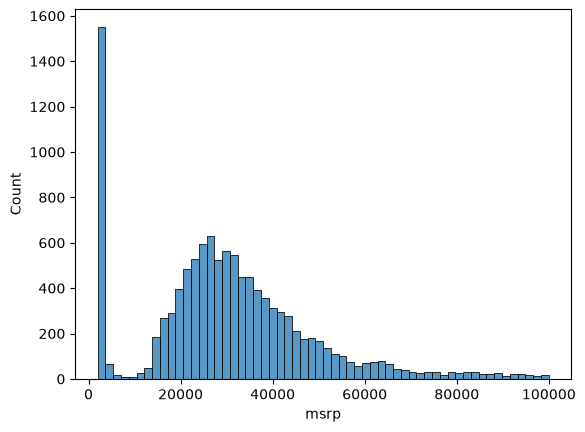

In [7]:
sns.histplot(data.msrp[data.msrp < 100000])

In [8]:
data["price_logs"] = np.log1p(data.msrp)

In [9]:
data.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp,price_logs
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135,10.739349
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650,10.612779
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350,10.500977
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450,10.290483
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500,10.448744


<Axes: xlabel='price_logs', ylabel='Count'>

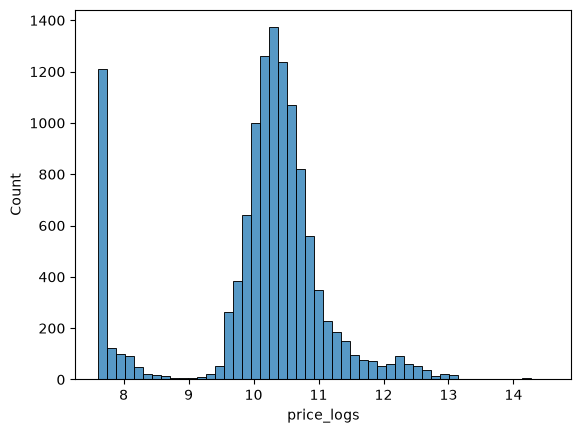

In [10]:
sns.histplot(data.price_logs, bins=50
            )

In [11]:
data.isnull().sum()

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
price_logs              0
dtype: int64

In [12]:
# Setting up

n = len(data)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

In [13]:
idx = np.arange(n)

In [14]:
np.random.seed(2)
np.random.shuffle(idx)

In [15]:
data_train = data.iloc[idx[:n_train]]
data_val = data.iloc[idx[n_train:n_train+n_val]]
data_test = data.iloc[idx[n_train+n_val:]]

In [16]:
data_train.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp,price_logs
2735,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385,14410,9.575747
6720,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,19685,9.887663
5878,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,19795,9.893235
11190,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873,2000,7.601402
4554,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657,56260,10.937757


In [17]:
len(data_train), len(data_val), len(data_test)

(7150, 2382, 2382)

In [18]:
data_train = data_train.reset_index(drop=True) 
data_val = data_val.reset_index(drop=True) 
data_test = data_test.reset_index(drop=True) 


In [19]:
y_train = data_train.price_logs.values
y_val = data_val.price_logs.values
y_test = data_test.price_logs.values

In [20]:
del data_train['msrp']
del data_val['msrp']
del data_test['msrp']

In [21]:
def linear_regression(xi):
    n = len(xi)
    pred = w0
    for j in range(n):
        pred = pred + w[j] * xi[j]
    return pred
    

In [22]:
xi = [100, 2020, 93234]
w0 = 0
w = [1 , 1, 1]

In [23]:
linear_regression(xi)

95354

In [24]:
# Create a vector-vector multiplication linear regression
def dot(xi, w):
    n = len(xi)
    res = 0.0
    for j in range(n):
        res = res + xi[j] * w[j]
    return res

In [25]:
def linear_regression(xi):
    return w0 + dot(xi, w)

In [26]:
w_new = [w0] + w
w_new

[0, 1, 1, 1]

In [27]:
def linear_regression(xi):
    xi = [1] + xi
    return dot(xi, w_new)

In [28]:
linear_regression(xi)

95354.0

In [29]:
# training a linear regression model

X = [
    [100, 20, 990],
    [90, 25, 1004],
    [110, 24, 880],
    [50, 21, 1003],
    [130, 25, 1002],
    [70, 24, 885],
    [120, 23, 995],
    [80, 21, 990],
    [99, 22, 770]
]
X = np.array(X)
X

array([[ 100,   20,  990],
       [  90,   25, 1004],
       [ 110,   24,  880],
       [  50,   21, 1003],
       [ 130,   25, 1002],
       [  70,   24,  885],
       [ 120,   23,  995],
       [  80,   21,  990],
       [  99,   22,  770]])

In [30]:
ones = np.ones(X.shape[0])
ones

array([1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [31]:
X = np.column_stack([ones, X])

In [32]:
XTX = X.T.dot(X)

In [33]:
XTX_inv = np.linalg.inv(XTX)

In [34]:
XTX.dot(XTX_inv)

array([[ 1.00000000e+00,  8.46842365e-18,  1.66608670e-15,
         6.39679282e-18],
       [-3.08857107e-12,  1.00000000e+00,  1.66119112e-13,
         9.26125496e-16],
       [ 7.57588436e-13,  6.50088470e-16,  1.00000000e+00,
        -6.53557070e-16],
       [-4.28160493e-11,  1.28414081e-14,  2.09905706e-12,
         1.00000000e+00]])

In [35]:
y = [10000, 20000, 15000, 10000, 23400, 12000, 12000, 20000, 25000]

In [36]:
w_full = XTX_inv.dot(X.T).dot(y)

In [37]:
w0 = w_full[0]
w = w_full[1:]

In [38]:
w0, w

(np.float64(13748.320662314465),
 array([ 64.65200802, 749.969335  , -21.71242569]))

In [39]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    XTX.dot(XTX_inv)

    w_full = XTX_inv.dot(X.T).dot(y)
    return w_full[0], w_full[1:] 

In [40]:
data_train.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
price_logs           float64
dtype: object

In [41]:
base = ['engine_hp', 'engine_cylinders', 'highway_mpg', 'city_mpg', 'popularity']
data_train[base]

,engine_hp,engine_cylinders,highway_mpg,city_mpg,popularity
0,148.0,4.0,33,24,1385
1,132.0,4.0,32,25,2031
2,148.0,4.0,37,28,640
3,90.0,4.0,18,16,873
4,385.0,8.0,21,15,5657
...,...,...,...,...,...
7145,300.0,6.0,31,20,3916
7146,210.0,4.0,30,24,873
7147,285.0,6.0,22,17,549
7148,563.0,12.0,21,13,86


In [42]:
X_train = data_train[base].values

In [43]:
X_train = data_train[base].fillna(0).values

In [44]:
w0, w = train_linear_regression(X_train, y_train)

In [45]:
y_pred = w0 + X_train.dot(w)

<Axes: ylabel='Count'>

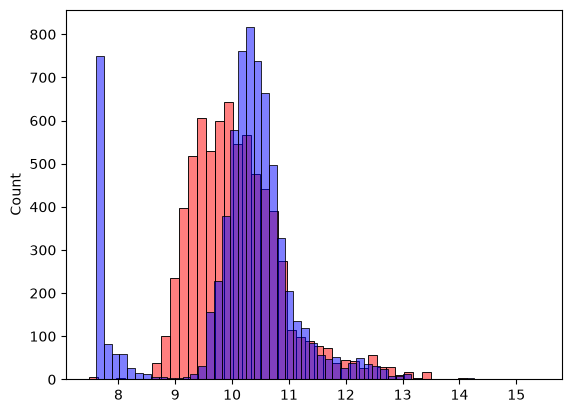

In [46]:
sns.histplot(y_pred, color='red', alpha=0.5, bins=50)
sns.histplot(y_train, color='blue', alpha=0.5, bins=50)

In [47]:
def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [48]:
rmse(y_train, y_pred)

np.float64(0.7554192603920132)

In [49]:
def prepare_X(data):
    data_num = data[base]
    data_num = data_num.fillna(0)
    X = data_num.values
    return X
    

In [50]:
X_val = prepare_X(data_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

np.float64(0.7616530991301627)

In [51]:
def prepare_X(data):
    data = data.copy()
    data['age'] = 2017 - data.year
    features = base + ['age']
    data_num = data[features]
    data_num = data_num.fillna(0)
    X = data_num.values
    return X

In [52]:
X_train = prepare_X(data_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(data_val)
y_pred = w0 + X_val.dot(w)

rmse(y_val, y_pred)

np.float64(0.5172055461058327)

<Axes: ylabel='Count'>

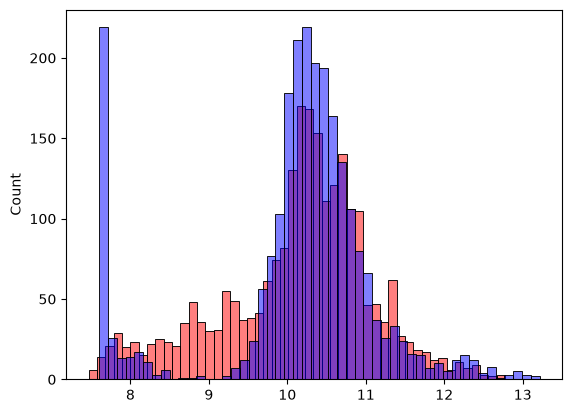

In [53]:
sns.histplot(y_pred, color='red', alpha=0.5, bins=50)
sns.histplot(y_val, color='blue', alpha=0.5, bins=50)

In [54]:
def prepare_X(data):
    data = data.copy()
    features = base.copy()
    
    data['age'] = 2017 - data.year
    features.append('age')

    for v in [2, 3, 4]:
        data['num_doors_%s' % v] = (data.number_of_doors == v).astype('int')
        features.append('num_doors_%s' % v)
    
    data_num = data[features]
    data_num = data_num.fillna(0)
    X = data_num.values
    return X

In [55]:
X_train = prepare_X(data_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(data_val)
y_pred = w0 + X_val.dot(w)

rmse(y_val, y_pred)



np.float64(0.5157995641501902)

<Axes: ylabel='Count'>

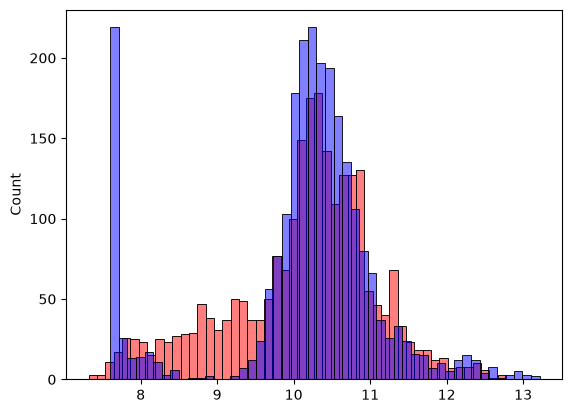

In [56]:
sns.histplot(y_pred, color='red', alpha=0.5, bins=50)
sns.histplot(y_val, color='blue', alpha=0.5, bins=50)

In [57]:
makes = list(data.make.value_counts().head().index)

In [58]:
def prepare_X(data):
    data = data.copy()
    features = base.copy()
    
    data['age'] = 2017 - data.year
    features.append('age')

    for v in [2, 3, 4]:
        data['num_doors_%s' % v] = (data.number_of_doors == v).astype('int')
        features.append('num_doors_%s' % v)
        
    for v in makes:
        data['make_%s' % v] = (data.make == v).astype('int')
        features.append('make_%s' % v)
    
    data_num = data[features]
    data_num = data_num.fillna(0)
    X = data_num.values
    return X

In [59]:
X_train = prepare_X(data_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(data_val)
y_pred = w0 + X_val.dot(w)

rmse(y_val, y_pred)

np.float64(0.5076038849556633)

In [60]:
data_train.dtypes


make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
price_logs           float64
dtype: object

In [61]:
categorical_variables = ['make', 'engine_fuel_type', 'transmission_type', 
                         'driven_wheels', 'market_category', 'vehicle_size', 'vehicle_style']
categories = {}

for c in categorical_variables:
    categories[c] = list(data[c].value_counts().head().index)

categories

{'make': ['chevrolet', 'ford', 'volkswagen', 'toyota', 'dodge'],
 'engine_fuel_type': ['regular_unleaded',
  'premium_unleaded_(required)',
  'premium_unleaded_(recommended)',
  'flex-fuel_(unleaded/e85)',
  'diesel'],
 'transmission_type': ['automatic',
  'manual',
  'automated_manual',
  'direct_drive',
  'unknown'],
 'driven_wheels': ['front_wheel_drive',
  'rear_wheel_drive',
  'all_wheel_drive',
  'four_wheel_drive'],
 'market_category': ['crossover',
  'flex_fuel',
  'luxury',
  'luxury,performance',
  'hatchback'],
 'vehicle_size': ['compact', 'midsize', 'large'],
 'vehicle_style': ['sedan',
  '4dr_suv',
  'coupe',
  'convertible',
  '4dr_hatchback']}

In [62]:
def prepare_X(data):
    data = data.copy()
    features = base.copy()
    
    data['age'] = 2017 - data.year
    features.append('age')

    for v in [2, 3, 4]:
        data['num_doors_%s' % v] = (data.number_of_doors == v).astype('int')
        features.append('num_doors_%s' % v)
        
    for c, values in categories.items():
        for v in values:
            data['%s_%s' % (c, v)] = (data[c] == v).astype('int')
            features.append('%s_%s' % (c, v))
    
    data_num = data[features]
    data_num = data_num.fillna(0)
    X = data_num.values
    return X

In [63]:
X_train = prepare_X(data_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(data_val)
y_pred = w0 + X_val.dot(w)

rmse(y_val, y_pred)

np.float64(20.255338567164987)